<a href="https://colab.research.google.com/github/Infix10/DC-LAB/blob/main/Lab%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def system_operator(x):
  x_padded = np.concatenate(([0],x))
  y = np.zeros(len(x))
  for n in range(1,len(x_padded)):
    y[n-1] = x_padded[n]-x_padded[n-1]
  return y
n = np.arange(10)
x1 = np.sin(2*np.pi*n/5)
x2 = np.cos(2*np.pi*n/10)
print("---Testing Linearity---")
print(f"Input x1: {x1.round(2)}")
print(f"Output y1 (H[x1]):{system_operator(x1).round(2)}")
print(f"\nInput x2: {x2.round(2)}")
print(f"Output y2 (h[x2]):{system_operator(x2).round(2)}")
a,b = 2, 3
x_sum = a*x1+b*x2
y_sum = system_operator(x_sum)
linearity_rhs = a*system_operator(x1)+b*system_operator(x2)
print(f"\nLinearity Test: H[a*x1+b*x2]={y_sum.round(2)}")
print(f"a*h[x1]+b*H[x2] = {linearity_rhs.round(2)}")
if np.allclose(y_sum,linearity_rhs):
  print("The system appears to be in LINEAR for this test.")
else:
  print("The system appears to be in NON-LINEAR for this test.")


---Testing Linearity---
Input x1: [ 0.    0.95  0.59 -0.59 -0.95 -0.    0.95  0.59 -0.59 -0.95]
Output y1 (H[x1]):[ 0.    0.95 -0.36 -1.18 -0.36  0.95  0.95 -0.36 -1.18 -0.36]

Input x2: [ 1.    0.81  0.31 -0.31 -0.81 -1.   -0.81 -0.31  0.31  0.81]
Output y2 (h[x2]):[ 1.   -0.19 -0.5  -0.62 -0.5  -0.19  0.19  0.5   0.62  0.5 ]

Linearity Test: H[a*x1+b*x2]=[ 3.    1.33 -2.23 -4.21 -2.23  1.33  2.48  0.77 -0.5   0.77]
a*h[x1]+b*H[x2] = [ 3.    1.33 -2.23 -4.21 -2.23  1.33  2.48  0.77 -0.5   0.77]
The system appears to be in LINEAR for this test.


In [ ]:
from os import system
print("\n---Testing Time-Invariance---")
x = np.sin(2*np.pi*n/5)
k = 3
x_shifted = np.roll(x,k)
x_shifted = np.roll(x,k)
x_shifted[:k] = 0
y=system_operator(x)
y_shifted_expected = np.roll(y,k)
y_shifted_expected[:k] = 0
y_from_shifted_input = system_operator(x_shifted)
print(f"Original signal x: {x.round(2)}")
print(f"Shifted signal x[n-{k}]: {x_shifted.round(2)}")
print(f"Output y[n] from original: {y.round(2)}")
print(f"Shifted output y[n-{k}] (expected):{y_shifted_expected.round(2)}")
print(f"Output from shifted input H[x[n-{k}]]:{y_from_shifted_input.round(2)}")
if np.allclose(y_from_shifted_input, y_shifted_expected):
  print("The system appears to be in TIME-INVARIANT for this test.")
else:
  print("The system appears to be in TIME-VARIANT for this test.")



---Testing Time-Invariance---
Original signal x: [ 0.    0.95  0.59 -0.59 -0.95 -0.    0.95  0.59 -0.59 -0.95]
Shifted signal x[n-3]: [ 0.    0.    0.    0.    0.95  0.59 -0.59 -0.95 -0.    0.95]
Output y[n] from original: [ 0.    0.95 -0.36 -1.18 -0.36  0.95  0.95 -0.36 -1.18 -0.36]
Shifted output y[n-3] (expected):[ 0.    0.    0.    0.    0.95 -0.36 -1.18 -0.36  0.95  0.95]
Output from shifted input H[x[n-3]]:[ 0.    0.    0.    0.    0.95 -0.36 -1.18 -0.36  0.95  0.95]
The system appears to be in TIME-INVARIANT for this test.


Testing Linearity
Homogenity Test: H[2*x1] vs 2*H[x1]
H[c*x]:[3.   5.35 6.8  6.8  5.35]...
c*H[x]: [6.   8.35 9.8  9.8  8.35]...
Equal? False

Superposition Test: H[a*x1 + b*x2] vs a*H[x1] + b*H[x2]
H[sum]: [ 9.    9.59  6.8   2.56 -0.65]...
aH[x1]+bH[x2]: [21.   21.59 18.8  14.56 11.35]...
Equal? False

 System is NON-LINEAR (affine due to constant B)

TESTING TIME INVARIANCE
Original x (first 10): [ 0.    0.95  0.59 -0.59 -0.95 -0.    0.95  0.59 -0.59 -0.95]
Shifted x[n-3] (first 10): [ 0.    0.    0.    0.    0.95  0.59 -0.59 -0.95 -0.    0.95]

H[x[n]] (first 10) : [3.   4.9  4.18 1.82 1.1  3.   4.9  4.18 1.82 1.1 ]
y[n-3] expected (first 10): [0.   0.   0.   3.   4.9  4.18 1.82 1.1  3.   4.9 ]
H[x[n-3]] (first 10): [3.   3.   3.   3.   4.9  4.18 1.82 1.1  3.   4.9 ]

System is TIME-VARIANT

TESTING CAUSALITY
y(n) depends Only on x(n) (current input)
NO dependence on future inputs like x(n+1),x(n+2),etc.

System is CAUSAL

TESTING STABILITY (BIBO)
Bounded input: |x|<=1 
Output rang

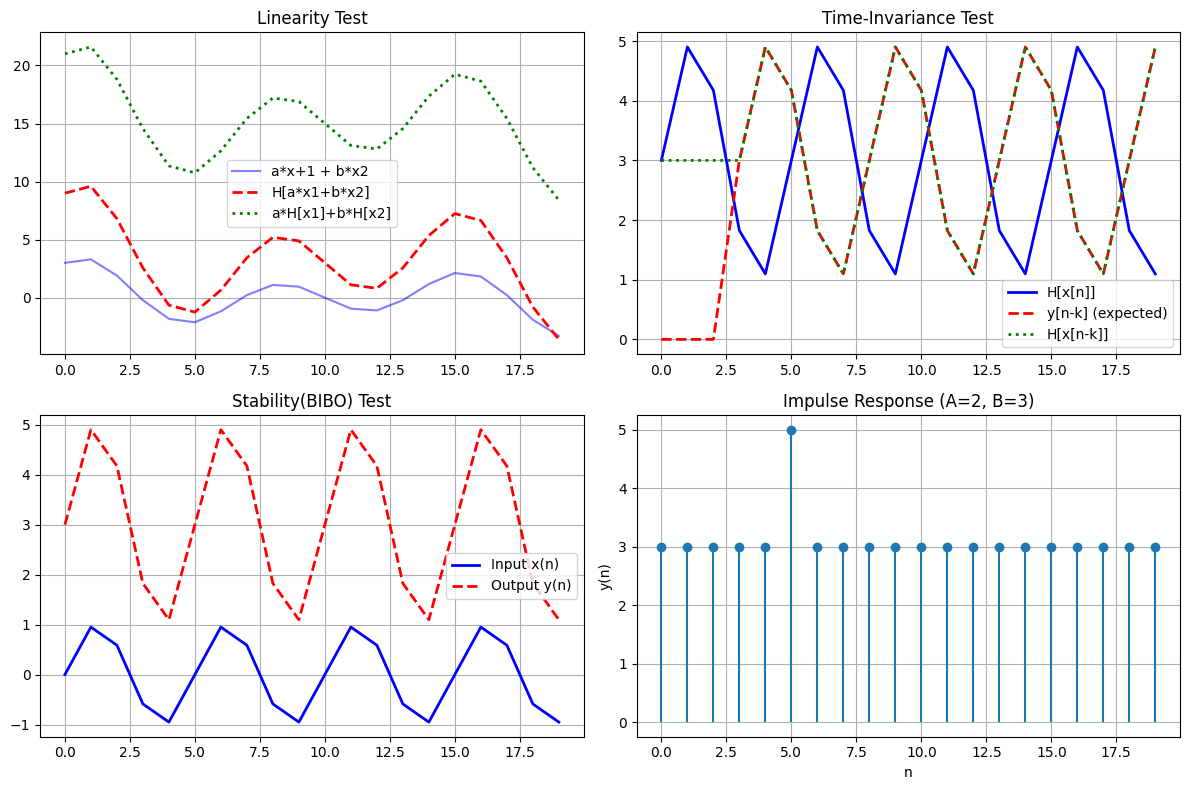

In [2]:
import numpy as np
import matplotlib.pyplot as plt
def system_operator(x, A=2, B=3):
  return A*x+B
A = 2
B = 3
N = 20
n = np.arange(N)
print("="*60)
print("Testing Linearity")
print("="*60)
x1 = np.sin(2*np.pi*n/10)
x2 = np.cos(2*np.pi*n/8)
a ,b = 2,3
y_superposition = system_operator(a*x1+b*x2,A,B)
y_linear_combination = a*system_operator(x1,A,B) + b*system_operator(x2,A,B)
c = 2
y_scaled_input = system_operator(c*x1,A,B)
y_scaled_output = c*system_operator(x1,A,B)
print(f"Homogenity Test: H[{c}*x1] vs {c}*H[x1]")
print(f"H[c*x]:{y_scaled_input[:5].round(2)}...")
print(f"c*H[x]: {y_scaled_output[:5].round(2)}...")
print(f"Equal? {np.allclose(y_scaled_input,y_scaled_output)}")
print(f"\nSuperposition Test: H[a*x1 + b*x2] vs a*H[x1] + b*H[x2]")
print(f"H[sum]: {y_superposition[:5].round(2)}...")
print(f"aH[x1]+bH[x2]: {y_linear_combination[:5].round(2)}...")
print(f"Equal? {np.allclose(y_superposition,y_linear_combination)}")
if np.allclose(y_scaled_input,y_scaled_output) and np.allclose(y_superposition,y_linear_combination):
  print("\nSystem is linear")
else:
  print("\n System is NON-LINEAR (affine due to constant B)")
print("\n"+"="*60)
print("TESTING TIME INVARIANCE")
print("="*60)
x = np.sin(2*np.pi *n/5)
k = 3
x_shifted = np.zeros_like(x)
x_shifted[k:] = x[:-k]
y = system_operator(x,A,B)
y_from_shifted_input = system_operator(x_shifted,A,B)
y_shifted_expected = np.zeros_like(y)
y_shifted_expected[k:] = y[:-k]
print(f"Original x (first 10): {x[:10].round(2)}")
print(f"Shifted x[n-{k}] (first 10): {x_shifted[:10].round(2)}")
print(f"\nH[x[n]] (first 10) : {y[:10].round(2)}")
print(f"y[n-{k}] expected (first 10): {y_shifted_expected[:10].round(2)}")
print(f"H[x[n-{k}]] (first 10): {y_from_shifted_input[:10].round(2)}")
if np.allclose(y_from_shifted_input,y_shifted_expected):
  print("\nSystem is TIME-INVARIANT")
else:
  print("\nSystem is TIME-VARIANT")
print("\n"+"="*60)
print("TESTING CAUSALITY")
print("="*60)
print("y(n) depends Only on x(n) (current input)")
print("NO dependence on future inputs like x(n+1),x(n+2),etc.")
print("\nSystem is CAUSAL")
print("\n"+"="*60)
print("TESTING STABILITY (BIBO)")
print("="*60)
x_bounded = np.sin(2*np.pi*n/5)
y_bounded = system_operator(x_bounded,A,B)
print(f"Bounded input: |x|<=1 ") # Fixed: Changed printf to print
print(f"Output range: min = {y_bounded.min():.2f},max={y_bounded.max():.2f}")
if np.all(np.isfinite(y_bounded)):
  max_output = np.max(np.abs(y_bounded))
  print(f"Maximum |y| = {max_output:.2f}")
  print(f"Since input is bounded and output is bounded, system is STABLE") # Fixed: Changed printf to print
  print("\nSystem is BIBO STABLE")
print("\n"+"="*60)
print("TESTING MEMORY")
print("="*60)
print("y(n)=A*x(n) + B depends only on x(n)")
print("NO dependence on x(n-1), x(n-2), or x(n+1)")
print("\nSystem is MEMORYLESS (static)")
print("\n"+"="*60)
print("VISUALIZATION")
print("="*60)
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes[0,0].plot(n,a*x1+b*x2, 'b-', label='a*x+1 + b*x2', alpha=0.5)
axes[0,0].plot(n,y_superposition, 'r--', label='H[a*x1+b*x2]',linewidth=2)
axes[0,0].plot(n,y_linear_combination, 'g:', label='a*H[x1]+b*H[x2]',linewidth=2)
axes[0,0].set_title('Linearity Test')
axes[0,0].legend()
axes[0,0].grid(True)


axes[0,1].plot(n,y,'b-',label='H[x[n]]',linewidth=2)
axes[0,1].plot(n,y_shifted_expected,'r--',label='y[n-k] (expected)',linewidth=2)
axes[0,1].plot(n,y_from_shifted_input,'g:',label='H[x[n-k]]',linewidth=2)
axes[0,1].set_title('Time-Invariance Test')
axes[0,1].legend()
axes[0,1].grid(True)



axes[1,0].plot(n,x_bounded, 'b-', label='Input x(n)',linewidth=2)
axes[1,0].plot(n,y_bounded, 'r--', label='Output y(n)',linewidth=2)
axes[1,0].set_title('Stability(BIBO) Test')
axes[1,0].legend()
axes[1,0].grid(True)



impulse = np.zeros(N)
impulse[5] = 1
impulse_response = system_operator(impulse, A, B)
axes[1,1].stem(n, impulse_response, basefmt=" ")
axes[1,1].set_title(f'Impulse Response (A={A}, B={B})')
axes[1,1].set_xlabel('n')
axes[1,1].set_ylabel('y(n)')
axes[1,1].grid(True)
plt.tight_layout()
plt.show()